# EGF Batch — Summary Analysis
**Conditions:** H23 Ctrl EGF · H23 607-ko EGF  
**Time points:** 5 min · 30 min · 60 min  
**Data:** `EGF_batch_blobs.csv` · `EGF_batch_cell_summary.csv`

## 0 · Install packages (run once, then restart kernel)

In [ ]:
import sys
!{sys.executable} -m pip install matplotlib seaborn pandas numpy scipy --quiet
print('Done — restart the kernel if this was the first install.')

## 1 · Imports & settings

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
DATA_DIR  = Path(r'Z:/Marta/20260218/2026-02-18-Decon/results')
FIG_DIR   = Path(r'C:/Users/NIC-ADMIN4/Workspace/Jupyter/jupyter_napari/Marta/figures')
FIG_DIR.mkdir(exist_ok=True)

BLOBS_CSV = DATA_DIR / 'EGF_batch_blobs.csv'
CELLS_CSV = DATA_DIR / 'EGF_batch_cell_summary.csv'

# ── style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.2)

# one colour per genotype × timepoint group
COND_PALETTE = {'Ctrl': '#4C72B0', '607-ko': '#DD8452'}
CHANNELS     = ['C0', 'C1', 'C2']
TIME_ORDER   = ['5min', '30min', '60min']
GENOTYPES    = ['Ctrl', '607-ko']

# 6-colour palette: one shade per group (Ctrl 5/30/60, 607-ko 5/30/60)
GROUP_PALETTE = {
    'Ctrl 5min'   : '#9ecae1', 'Ctrl 30min'   : '#4292c6', 'Ctrl 60min'   : '#084594',
    '607-ko 5min' : '#fdae6b', '607-ko 30min' : '#f16913', '607-ko 60min' : '#7f2704',
}
GROUP_ORDER = list(GROUP_PALETTE.keys())

DPI = 150
print('Ready.')

## 2 · Load & parse data

In [ ]:
def parse_condition(fname):
    m = re.search(r'H23 (Ctrl|607-ko) EGF (\d+min)', str(fname))
    if m:
        return m.group(1), m.group(2)
    return None, None

blobs_raw = pd.read_csv(BLOBS_CSV)
blobs_raw[['genotype', 'timepoint']] = blobs_raw['file'].apply(
    lambda f: pd.Series(parse_condition(f)))
blobs = blobs_raw.dropna(subset=['genotype', 'timepoint']).copy()
blobs['timepoint'] = pd.Categorical(blobs['timepoint'], categories=TIME_ORDER, ordered=True)
blobs['group']     = blobs['genotype'] + ' ' + blobs['timepoint'].astype(str)

cells_raw = pd.read_csv(CELLS_CSV)
cells_raw[['genotype', 'timepoint']] = cells_raw['file'].apply(
    lambda f: pd.Series(parse_condition(f)))
cells = cells_raw.dropna(subset=['genotype', 'timepoint']).copy()
cells['timepoint'] = pd.Categorical(cells['timepoint'], categories=TIME_ORDER, ordered=True)
cells['group']     = cells['genotype'] + ' ' + cells['timepoint'].astype(str)

print(f'Blobs : {len(blobs):,} rows  |  excluded {len(blobs_raw)-len(blobs)} non-EGF')
print(f'Cells : {len(cells):,} rows  |  excluded {len(cells_raw)-len(cells)} non-EGF')
print()
print(cells.groupby(['genotype','timepoint']).size().rename('n_cells').to_frame())

In [ ]:
display(blobs.head(3))
display(cells.head(3))

## 3 · Overview statistics

In [7]:
blob_counts = (blobs
    .groupby(['genotype', 'timepoint', 'file', 'cell_id', 'channel'])
    .size().reset_index(name='n_blobs'))

# add group label back after groupby
blob_counts['group'] = blob_counts['genotype'] + ' ' + blob_counts['timepoint'].astype(str)

print('=== Blobs per cell per channel ===')
display(blob_counts.groupby(['genotype','timepoint','channel'])['n_blobs']
        .describe().round(2))

print('\n=== Blob volume (µm³) ===')
display(blobs.groupby(['genotype','timepoint','channel'])['volume_um3']
        .describe().round(4))

print('\n=== Distance to nucleus (µm) ===')
display(blobs.groupby(['genotype','timepoint','channel'])['dist_to_nucleus_um']
        .describe().round(3))

print('\n=== Distance to membrane (µm) ===')
display(blobs.groupby(['genotype','timepoint','channel'])['dist_to_surface_um']
        .describe().round(3))

=== Blobs per cell per channel ===


count   mean    std  min    25%   50%     75%  \
genotype timepoint channel                                                  
607-ko   5min      C0       201.0  47.23  31.32  1.0  26.00  44.0   63.00   
                   C1       201.0  86.92  60.32  1.0  46.00  80.0  113.00   
                   C2       199.0  25.53  16.79  1.0  15.50  24.0   33.00   
         30min     C0       191.0  46.85  30.30  1.0  27.50  44.0   63.00   
                   C1       191.0  66.09  44.77  1.0  32.50  61.0   92.00   
                   C2       188.0  26.86  17.32  1.0  16.75  24.5   36.00   
         60min     C0       197.0  40.42  28.85  1.0  18.00  38.0   54.00   
                   C1       196.0  78.83  52.71  1.0  36.75  74.5  112.75   
                   C2       196.0  23.78  13.95  1.0  11.00  24.0   34.00   
Ctrl     5min      C0       408.0  38.52  32.28  1.0  12.00  32.0   56.00   
                   C1       407.0  76.81  68.09  1.0  23.00  65.0  112.00   
                   C2       405.0  26.87  23.81  1.0   9.00  21.0   38.00   
         30min     C0       217.0  54.35  42.72  1.0  19.00  44.0   76.00   
                   C1       218.0  78.89  64.07  1.0  30.50  63.0  115.75   
                   C2       218.0  35.78  26.19  1.0  18.00  31.0   49.00   
         60min     C0       262.0  40.63  30.80  1.0  15.25  36.0   57.00   
                   C1       263.0  79.62  59.13  1.0  31.50  73.0  115.50   
                   C2       262.0  33.95  25.20  1.0  13.25  30.0   48.75   

                              max  
genotype timepoint channel         
607-ko   5min      C0       167.0  
                   C1       371.0  
                   C2       111.0  
         30min     C0       237.0  
                   C1       315.0  
                   C2       125.0  
         60min     C0       132.0  
                   C1       229.0  
                   C2        60.0  
Ctrl     5min      C0       191.0  
                   C1       409.0  
                   C2       148.0  
         30min     C0       195.0  
                   C1       292.0  
                   C2       115.0  
         60min     C0       168.0  
                   C1       334.0  
                   C2       154.0


=== Blob volume (µm³) ===


count    mean     std     min     25%     50%  \
genotype timepoint channel                                                    
607-ko   5min      C0        9493.0  0.0365  0.0319  0.0112  0.0165  0.0266   
                   C1       17471.0  0.0394  0.0373  0.0112  0.0181  0.0282   
                   C2        5081.0  0.0635  0.1091  0.0112  0.0181  0.0319   
         30min     C0        8949.0  0.0391  0.0365  0.0112  0.0165  0.0266   
                   C1       12624.0  0.0757  0.0965  0.0112  0.0197  0.0394   
                   C2        5050.0  0.0519  0.0940  0.0112  0.0176  0.0288   
         60min     C0        7963.0  0.0371  0.0319  0.0112  0.0165  0.0256   
                   C1       15450.0  0.0525  0.0768  0.0112  0.0176  0.0298   
                   C2        4661.0  0.0529  0.0940  0.0112  0.0176  0.0298   
Ctrl     5min      C0       15715.0  0.0302  0.0241  0.0112  0.0154  0.0224   
                   C1       31261.0  0.0357  0.0361  0.0112  0.0165  0.0250   
                   C2       10884.0  0.0487  0.0721  0.0112  0.0170  0.0277   
         30min     C0       11794.0  0.0308  0.0298  0.0112  0.0149  0.0213   
                   C1       17197.0  0.0704  0.0867  0.0112  0.0181  0.0346   
                   C2        7800.0  0.0396  0.0501  0.0112  0.0160  0.0250   
         60min     C0       10646.0  0.0291  0.0222  0.0112  0.0149  0.0213   
                   C1       20941.0  0.0523  0.0652  0.0112  0.0176  0.0304   
                   C2        8895.0  0.0400  0.0486  0.0112  0.0160  0.0250   

                               75%     max  
genotype timepoint channel                  
607-ko   5min      C0       0.0447  0.6672  
                   C1       0.0474  1.8163  
                   C2       0.0650  2.4696  
         30min     C0       0.0479  0.5634  
                   C1       0.0948  1.8461  
                   C2       0.0559  3.3285  
         60min     C0       0.0453  0.3152  
                   C1       0.0602  3.8967  
                   C2       0.0575  2.9127  
Ctrl     5min      C0       0.0362  0.8898  
                   C1       0.0421  1.4941  
                   C2       0.0522  1.5479  
         30min     C0       0.0351  0.9398  
                   C1       0.0868  0.9947  
                   C2       0.0442  1.0942  
         60min     C0       0.0346  0.2588  
                   C1       0.0607  2.7657  
                   C2       0.0447  1.2141


=== Distance to nucleus (µm) ===


count    mean    std    min    25%    50%  \
genotype timepoint channel                                                
607-ko   5min      C0        9493.0   8.413  4.161  0.346  5.626  7.767   
                   C1       17471.0   8.287  4.446  0.308  5.118  7.504   
                   C2        5081.0   7.786  3.942  0.389  5.143  7.172   
         30min     C0        8949.0   8.122  4.049  0.471  5.582  7.472   
                   C1       12624.0   7.774  3.828  0.268  5.378  7.295   
                   C2        5050.0   7.975  4.025  0.369  5.396  7.313   
         60min     C0        7963.0   8.205  3.728  0.374  5.722  7.825   
                   C1       15450.0   7.734  3.456  0.268  5.420  7.448   
                   C2        4661.0   7.877  3.543  0.680  5.546  7.452   
Ctrl     5min      C0       15715.0   9.414  5.654  0.270  5.850  8.194   
                   C1       31261.0   9.676  6.508  0.332  5.455  8.108   
                   C2       10884.0   8.402  4.999  0.287  5.333  7.442   
         30min     C0       11794.0  10.153  4.587  0.388  7.031  9.588   
                   C1       17197.0   9.069  4.423  0.287  6.082  8.522   
                   C2        7800.0   9.262  4.430  0.274  6.282  8.631   
         60min     C0       10646.0   9.115  3.963  0.652  6.497  8.705   
                   C1       20941.0   8.450  3.831  0.219  5.888  8.094   
                   C2        8895.0   8.491  3.781  0.361  6.027  8.055   

                               75%     max  
genotype timepoint channel                  
607-ko   5min      C0       10.583  35.461  
                   C1       10.585  35.558  
                   C2        9.696  33.001  
         30min     C0        9.915  35.817  
                   C1        9.493  37.302  
                   C2        9.713  37.319  
         60min     C0       10.255  32.905  
                   C1        9.581  34.218  
                   C2        9.599  25.917  
Ctrl     5min      C0       11.460  61.740  
                   C1       11.963  65.133  
                   C2       10.120  56.920  
         30min     C0       12.590  39.070  
                   C1       11.330  37.651  
                   C2       11.356  35.571  
         60min     C0       11.176  35.877  
                   C1       10.415  35.364  
                   C2       10.408  33.185


=== Distance to membrane (µm) ===


count   mean    std    min    25%    50%    75%  \
genotype timepoint channel                                                      
607-ko   5min      C0        9493.0  2.273  1.312  0.090  1.301  2.084  3.051   
                   C1       17471.0  2.196  1.354  0.090  1.170  2.015  2.990   
                   C2        5081.0  2.520  1.356  0.128  1.511  2.451  3.371   
         30min     C0        8949.0  2.131  1.334  0.090  1.154  1.876  2.876   
                   C1       12624.0  2.307  1.404  0.000  1.230  2.115  3.169   
                   C2        5050.0  2.161  1.326  0.090  1.109  1.997  2.999   
         60min     C0        7963.0  2.179  1.324  0.000  1.203  1.941  2.906   
                   C1       15450.0  2.397  1.380  0.064  1.376  2.234  3.193   
                   C2        4661.0  2.227  1.326  0.128  1.205  2.111  3.036   
Ctrl     5min      C0       15715.0  1.957  1.198  0.090  1.159  1.710  2.459   
                   C1       31261.0  1.760  1.217  0.064  0.910  1.513  2.257   
                   C2       10884.0  2.384  1.474  0.090  1.329  2.105  3.158   
         30min     C0       11794.0  1.966  1.318  0.064  1.073  1.731  2.516   
                   C1       17197.0  2.364  1.555  0.064  1.294  2.097  3.106   
                   C2        7800.0  2.244  1.533  0.090  1.169  1.977  2.915   
         60min     C0       10646.0  1.819  1.272  0.090  0.933  1.533  2.327   
                   C1       20941.0  2.109  1.443  0.090  1.064  1.810  2.791   
                   C2        8895.0  2.051  1.407  0.064  1.028  1.749  2.767   

                               max  
genotype timepoint channel          
607-ko   5min      C0       10.044  
                   C1       11.856  
                   C2        9.699  
         30min     C0        9.466  
                   C1        9.304  
                   C2        9.207  
         60min     C0        8.764  
                   C1        9.767  
                   C2        8.911  
Ctrl     5min      C0       11.812  
                   C1       10.632  
                   C2       11.811  
         30min     C0       10.078  
                   C1       10.870  
                   C2       11.089  
         60min     C0       10.777  
                   C1       11.212  
                   C2        9.411

## 4 · Blob counts per cell
Distribution of blob counts per cell for each channel, split by group.

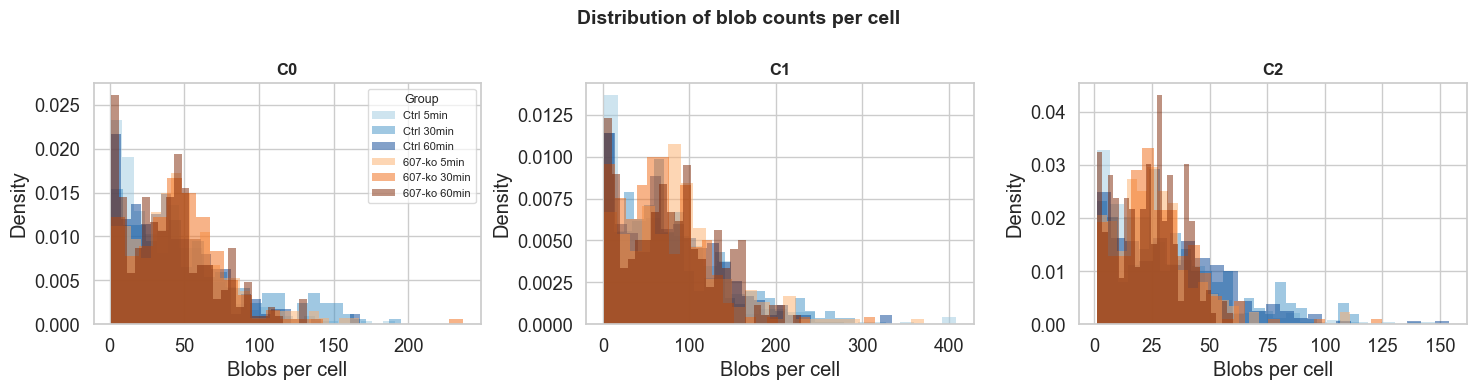

Saved → figures/blob_count_histogram.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, ch in zip(axes, CHANNELS):
    sub = blob_counts[blob_counts['channel'] == ch]
    for grp in GROUP_ORDER:
        data = sub[sub['group'] == grp]['n_blobs']
        ax.hist(data, bins=25, alpha=0.5, label=grp,
                color=GROUP_PALETTE[grp], edgecolor='none', density=True)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Blobs per cell')
    ax.set_ylabel('Density')

axes[0].legend(title='Group', fontsize=8, title_fontsize=9,
               loc='upper right', framealpha=0.7)
fig.suptitle('Distribution of blob counts per cell', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_count_histogram.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_count_histogram.png')

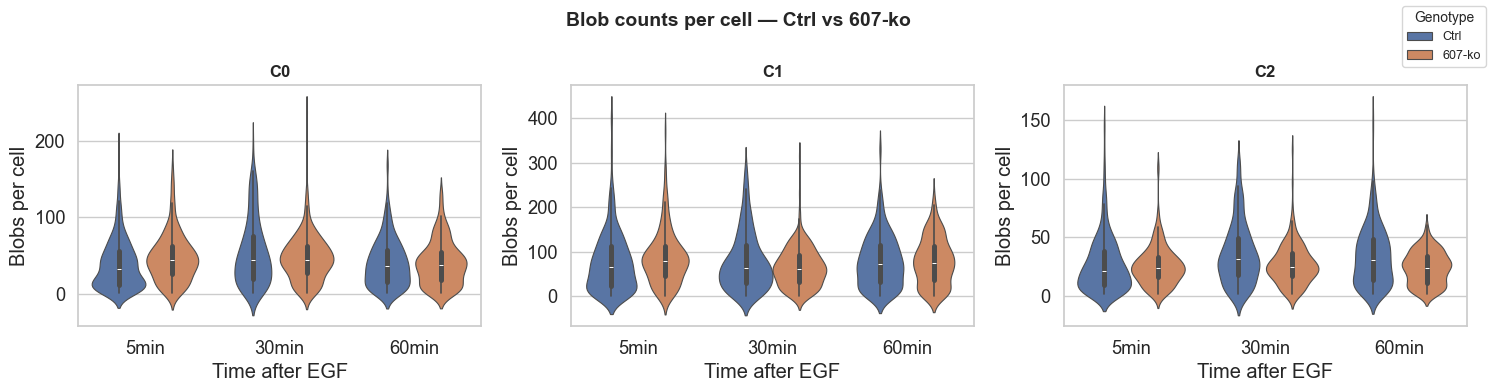

Saved → figures/blob_count_violin.png


In [12]:
# Violin of blob count per cell grouped by timepoint × genotype
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, ch in zip(axes, CHANNELS):
    sub = blob_counts[blob_counts['channel'] == ch].copy()
    sub['timepoint'] = sub['timepoint'].astype(str)
    sns.violinplot(data=sub, x='timepoint', y='n_blobs', hue='genotype',
                   order=TIME_ORDER, hue_order=GENOTYPES,
                   palette=COND_PALETTE, inner='box', split=False,
                   linewidth=0.8, ax=ax)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time after EGF')
    ax.set_ylabel('Blobs per cell')
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, GENOTYPES, title='Genotype', loc='upper right',
           fontsize=9, title_fontsize=10, framealpha=0.8)
fig.suptitle('Blob counts per cell — Ctrl vs 607-ko', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_count_violin.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_count_violin.png')

## 5 · Blob volume distribution

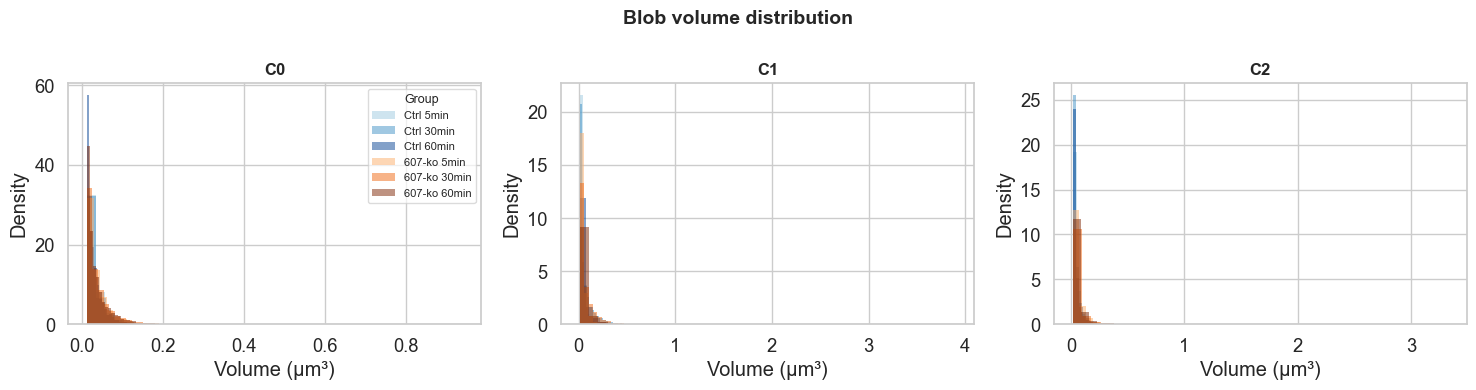

Saved → figures/blob_volume_histogram.png


In [13]:
# Overlapping histograms of blob volume per channel
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, ch in zip(axes, CHANNELS):
    sub = blobs[blobs['channel'] == ch]
    for grp in GROUP_ORDER:
        data = sub[sub['group'] == grp]['volume_um3'].dropna()
        ax.hist(data, bins=40, alpha=0.5, label=grp,
                color=GROUP_PALETTE[grp], edgecolor='none', density=True)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Volume (µm³)')
    ax.set_ylabel('Density')

axes[0].legend(title='Group', fontsize=8, title_fontsize=9, framealpha=0.7)
fig.suptitle('Blob volume distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_volume_histogram.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_volume_histogram.png')

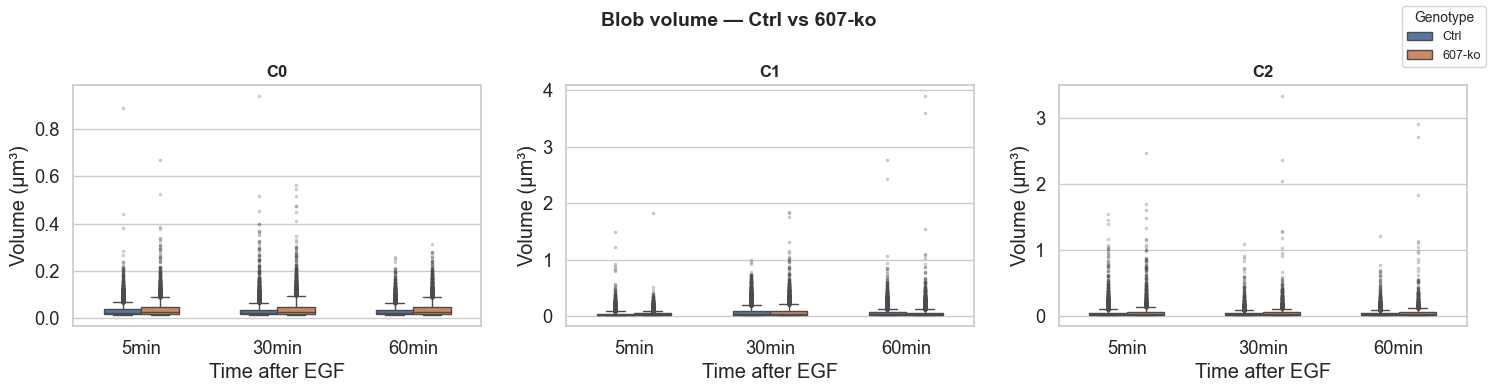

Saved → figures/blob_volume_boxplot.png


In [14]:
# Boxplot of blob volume grouped by timepoint × genotype
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, ch in zip(axes, CHANNELS):
    sub = blobs[blobs['channel'] == ch].copy()
    sub['timepoint'] = sub['timepoint'].astype(str)
    sns.boxplot(data=sub, x='timepoint', y='volume_um3', hue='genotype',
                order=TIME_ORDER, hue_order=GENOTYPES,
                palette=COND_PALETTE, width=0.55, linewidth=1.0,
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3), ax=ax)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time after EGF')
    ax.set_ylabel('Volume (µm³)')
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, GENOTYPES, title='Genotype', loc='upper right',
           fontsize=9, title_fontsize=10, framealpha=0.8)
fig.suptitle('Blob volume — Ctrl vs 607-ko', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_volume_boxplot.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_volume_boxplot.png')

## 6 · Intensity analysis
Mean fluorescence intensity of each blob measured in its own channel.

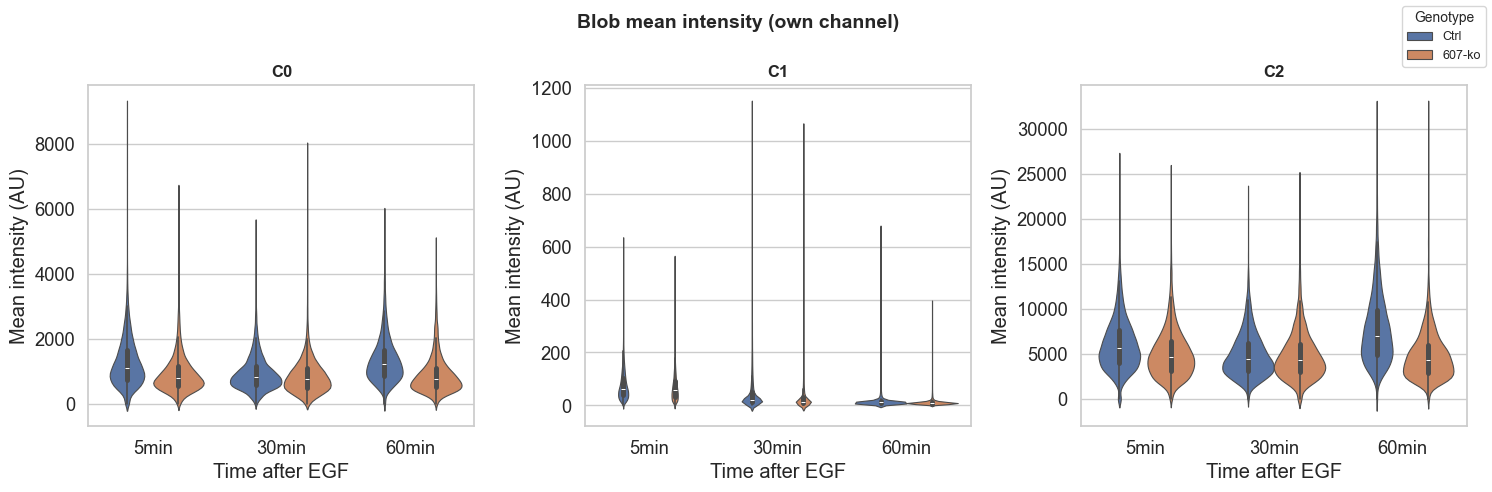

Saved → figures/blob_mean_intensity_violin.png


In [15]:
CH_INT = {'C0': 'ch0_mean_intensity',
          'C1': 'ch1_mean_intensity',
          'C2': 'ch2_mean_intensity'}

# Build long-form intensity df
int_parts = []
for ch, col in CH_INT.items():
    sub = blobs[blobs['channel'] == ch][['group','genotype','timepoint', col]].dropna().copy()
    sub = sub.rename(columns={col: 'mean_intensity'})
    sub['channel'] = ch
    int_parts.append(sub)
int_df = pd.concat(int_parts, ignore_index=True)
int_df['timepoint'] = int_df['timepoint'].astype(str)

# Violin plot — one panel per channel
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, ch in zip(axes, CHANNELS):
    sub = int_df[int_df['channel'] == ch]
    sns.violinplot(data=sub, x='timepoint', y='mean_intensity', hue='genotype',
                   order=TIME_ORDER, hue_order=GENOTYPES,
                   palette=COND_PALETTE, inner='box', split=False,
                   linewidth=0.8, ax=ax)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time after EGF')
    ax.set_ylabel('Mean intensity (AU)')
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, GENOTYPES, title='Genotype', loc='upper right',
           fontsize=9, title_fontsize=10, framealpha=0.8)
fig.suptitle('Blob mean intensity (own channel)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_mean_intensity_violin.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_mean_intensity_violin.png')

In [16]:
# Descriptive stats: mean intensity per group
print('=== Mean intensity per group per channel ===')
display(int_df.groupby(['channel','genotype','timepoint'])['mean_intensity']
        .describe().round(2))

=== Mean intensity per group per channel ===


count     mean      std    min      25%  \
channel genotype timepoint                                              
C0      607-ko   30min       8949.0   845.48   544.45   0.76   483.23   
                 5min        9493.0   936.30   629.21   1.72   543.21   
                 60min       7963.0   895.72   573.48   0.01   507.30   
        Ctrl     30min      11794.0   933.94   528.23   1.82   580.02   
                 5min       15715.0  1262.62   760.66   0.03   738.03   
                 60min      10646.0  1339.65   696.82   0.48   857.04   
C1      607-ko   30min      12624.0    38.11    67.60   1.33     9.69   
                 5min       17471.0    69.03    49.15   2.71    33.47   
                 60min      15450.0    12.46    16.92   1.65     7.01   
        Ctrl     30min      17197.0    52.38    78.36   2.12    14.01   
                 5min       31261.0    77.90    54.83   1.69    38.15   
                 60min      20941.0    18.44    32.26   2.19     8.63   
C2      607-ko   30min       5050.0  4847.05  2694.24   2.37  3001.92   
                 5min        5081.0  5073.27  2661.08  78.49  3188.72   
                 60min       4661.0  4867.30  2798.72   5.04  2946.39   
        Ctrl     30min       7800.0  4922.48  2444.28   0.64  3145.24   
                 5min       10884.0  6074.28  2872.18   0.09  4022.07   
                 60min       8895.0  7798.66  3920.26   0.08  4927.49   

                                50%      75%       max  
channel genotype timepoint                              
C0      607-ko   30min       751.39  1088.22   7866.69  
                 5min        786.65  1152.18   6538.31  
                 60min       754.00  1110.42   4932.51  
        Ctrl     30min       823.24  1157.60   5514.40  
                 5min       1108.36  1644.68   9113.20  
                 60min      1206.92  1659.72   5810.43  
C1      607-ko   30min        13.91    30.21   1045.40  
                 5min         57.74    91.46    551.20  
                 60min         9.20    12.64    391.39  
        Ctrl     30min        21.07    52.33   1129.03  
                 5min         63.56   104.56    621.64  
                 60min        11.08    15.13    670.54  
C2      607-ko   30min      4327.59  6142.73  24219.58  
                 5min       4671.22  6430.72  25013.46  
                 60min      4328.15  6065.71  32074.47  
        Ctrl     30min      4423.14  6272.25  22869.06  
                 5min       5636.17  7669.64  26426.37  
                 60min      7045.82  9929.52  31818.20

## 7 · Spatial distribution — distance to surface & nucleus

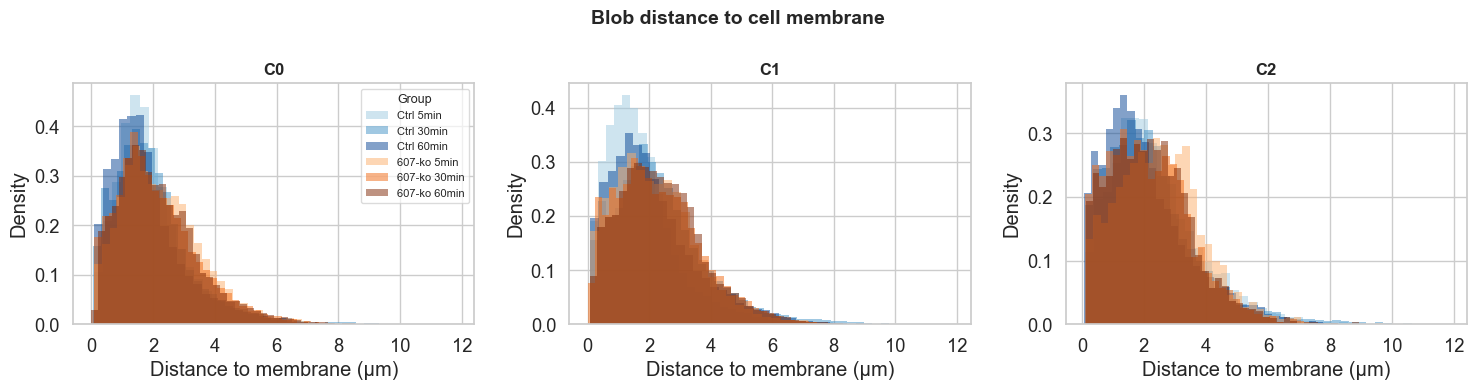

Saved → figures/blob_dist_membrane_histogram.png


In [17]:
# Overlapping histograms — distance to cell surface
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ch in zip(axes, CHANNELS):
    sub = blobs[blobs['channel'] == ch]
    for grp in GROUP_ORDER:
        data = sub[sub['group'] == grp]['dist_to_surface_um'].dropna()
        ax.hist(data, bins=40, alpha=0.5, label=grp,
                color=GROUP_PALETTE[grp], edgecolor='none', density=True)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Distance to membrane (µm)')
    ax.set_ylabel('Density')

axes[0].legend(title='Group', fontsize=8, title_fontsize=9, framealpha=0.7)
fig.suptitle('Blob distance to cell membrane', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_dist_membrane_histogram.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_dist_membrane_histogram.png')

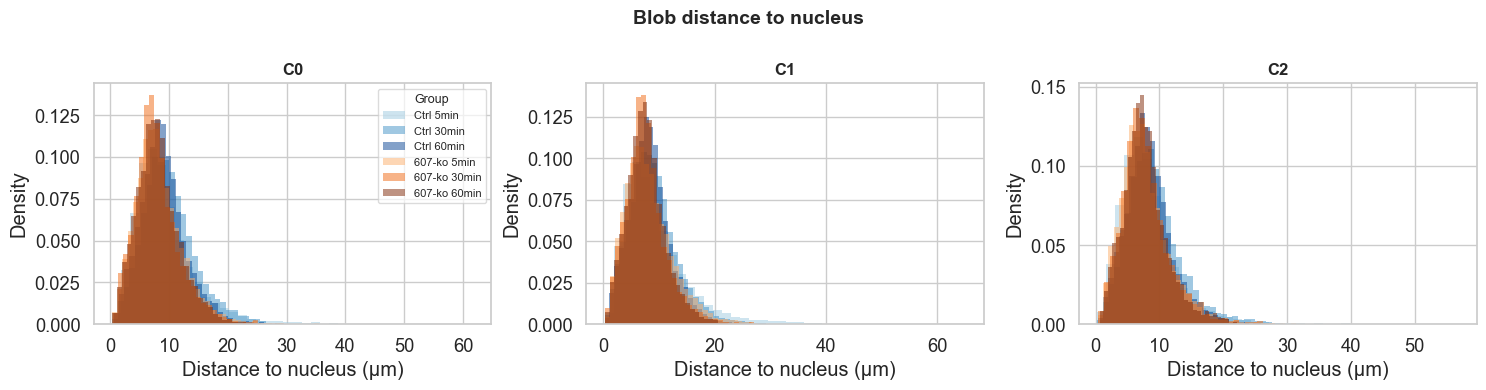

Saved → figures/blob_dist_nucleus_histogram.png


In [18]:
# Overlapping histograms — distance to nucleus
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ch in zip(axes, CHANNELS):
    sub = blobs[blobs['channel'] == ch]
    for grp in GROUP_ORDER:
        data = sub[sub['group'] == grp]['dist_to_nucleus_um'].dropna()
        ax.hist(data, bins=40, alpha=0.5, label=grp,
                color=GROUP_PALETTE[grp], edgecolor='none', density=True)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Distance to nucleus (µm)')
    ax.set_ylabel('Density')

axes[0].legend(title='Group', fontsize=8, title_fontsize=9, framealpha=0.7)
fig.suptitle('Blob distance to nucleus', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_dist_nucleus_histogram.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_dist_nucleus_histogram.png')

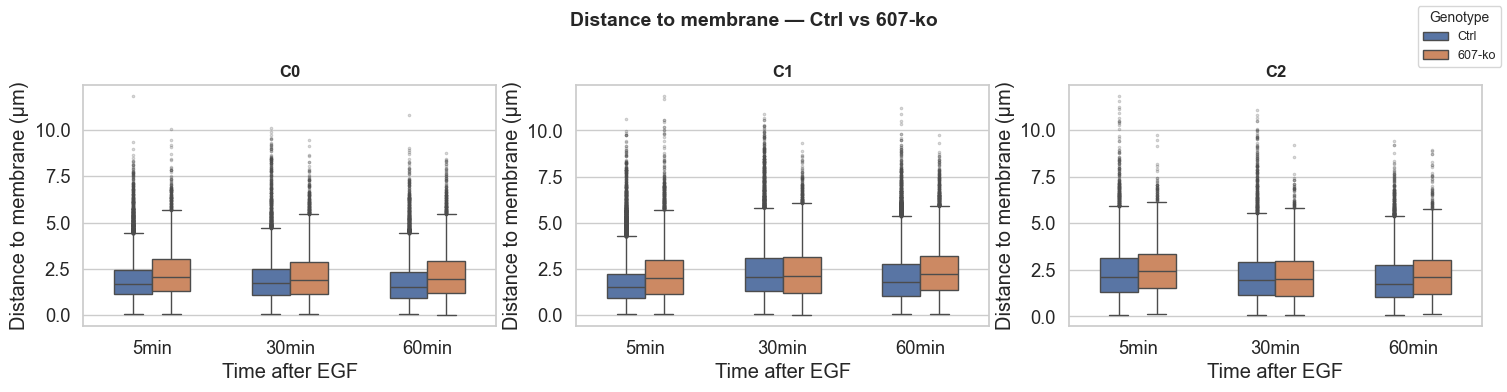

Saved → figures/blob_dist_membrane_boxplot.png


In [19]:
# Boxplot — distance to membrane per timepoint × genotype
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, ch in zip(axes, CHANNELS):
    sub = blobs[blobs['channel'] == ch].copy()
    sub['timepoint'] = sub['timepoint'].astype(str)
    sns.boxplot(data=sub, x='timepoint', y='dist_to_surface_um', hue='genotype',
                order=TIME_ORDER, hue_order=GENOTYPES,
                palette=COND_PALETTE, width=0.55, linewidth=1.0,
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3), ax=ax)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time after EGF')
    ax.set_ylabel('Distance to membrane (µm)')
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, GENOTYPES, title='Genotype', loc='upper right',
           fontsize=9, title_fontsize=10, framealpha=0.8)
fig.suptitle('Distance to membrane — Ctrl vs 607-ko', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_dist_membrane_boxplot.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_dist_membrane_boxplot.png')

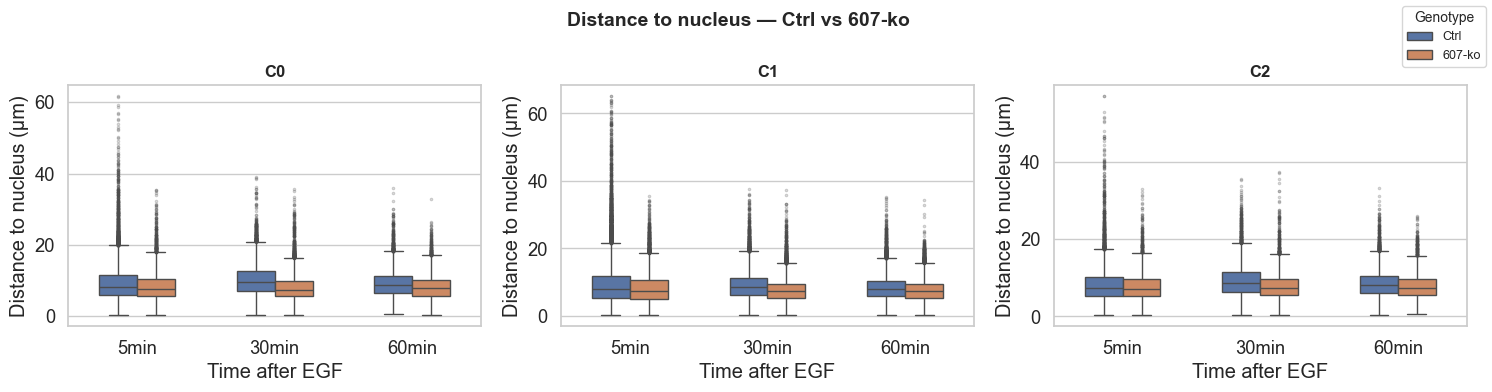

Saved → figures/blob_dist_nucleus_boxplot.png


In [20]:
# Boxplot — distance to nucleus per timepoint × genotype
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, ch in zip(axes, CHANNELS):
    sub = blobs[blobs['channel'] == ch].copy()
    sub['timepoint'] = sub['timepoint'].astype(str)
    sns.boxplot(data=sub, x='timepoint', y='dist_to_nucleus_um', hue='genotype',
                order=TIME_ORDER, hue_order=GENOTYPES,
                palette=COND_PALETTE, width=0.55, linewidth=1.0,
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3), ax=ax)
    ax.set_title(f'{ch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time after EGF')
    ax.set_ylabel('Distance to nucleus (µm)')
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, GENOTYPES, title='Genotype', loc='upper right',
           fontsize=9, title_fontsize=10, framealpha=0.8)
fig.suptitle('Distance to nucleus — Ctrl vs 607-ko', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'blob_dist_nucleus_boxplot.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved → figures/blob_dist_nucleus_boxplot.png')

## 8 · Export summary table

In [21]:
rows = []
for geno in GENOTYPES:
    for tp in TIME_ORDER:
        b = blobs[(blobs['genotype']==geno) & (blobs['timepoint']==tp)]
        c = cells[(cells['genotype']==geno) & (cells['timepoint']==tp)]
        row = {'Genotype': geno, 'Timepoint': tp,
               'N cells': c['cell_id'].nunique()}
        for ch in CHANNELS:
            bch = b[b['channel']==ch]
            idx = CHANNELS.index(ch)
            row[f'{ch} blobs/cell']     = round(bch.groupby(['file','cell_id']).size().mean(), 1)
            row[f'{ch} vol µm³']        = round(bch['volume_um3'].mean(), 4)
            row[f'{ch} intensity']      = round(bch[f'ch{idx}_mean_intensity'].mean(), 2)
            row[f'{ch} dist nucleus µm']= round(bch['dist_to_nucleus_um'].mean(), 3)
            row[f'{ch} dist surf µm']   = round(bch['dist_to_surface_um'].mean(), 3)
        rows.append(row)

summary = pd.DataFrame(rows)
display(summary)
out = FIG_DIR / 'EGF_analysis_summary.csv'
summary.to_csv(out, index=False)
print(f'Saved → {out}')

,Genotype,Timepoint,N cells,C0 blobs/cell,C0 vol µm³,C0 intensity,C0 dist nucleus µm,C0 dist surf µm,C1 blobs/cell,C1 vol µm³,C1 intensity,C1 dist nucleus µm,C1 dist surf µm,C2 blobs/cell,C2 vol µm³,C2 intensity,C2 dist nucleus µm,C2 dist surf µm
0,Ctrl,5min,50,38.5,0.0302,1262.62,9.414,1.957,76.8,0.0357,77.90,9.676,1.760,26.9,0.0487,6074.28,8.402,2.384
1,Ctrl,30min,35,54.4,0.0308,933.94,10.153,1.966,78.9,0.0704,52.38,9.069,2.364,35.8,0.0396,4922.48,9.262,2.244
2,Ctrl,60min,54,40.6,0.0291,1339.65,9.115,1.819,79.6,0.0523,18.44,8.450,2.109,34.0,0.0400,7798.66,8.491,2.051
3,607-ko,5min,28,47.2,0.0365,936.30,8.413,2.273,86.9,0.0394,69.03,8.287,2.196,25.5,0.0635,5073.27,7.786,2.520
4,607-ko,30min,31,46.9,0.0391,845.48,8.122,2.131,66.1,0.0757,38.11,7.774,2.307,26.9,0.0519,4847.05,7.975,2.161
5,607-ko,60min,34,40.4,0.0371,895.72,8.205,2.179,78.8,0.0525,12.46,7.734,2.397,23.8,0.0529,4867.30,7.877,2.227


Saved → C:\Users\NIC-ADMIN4\Workspace\Jupyter\jupyter_napari\Marta\figures\EGF_analysis_summary.csv
